## Model

In [1]:
# --- 环境导入 ---
import sys
sys.path.append('/cpfs04/user/hanyujin/rule-gen/rule_tokenizer')
import torch
from modelling.sit import SiT_models
from modelling.tokenizer import SoftVQModel
from modelling.samplers import euler_sampler
from utils.model import build_tokenizer
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
# --- 参数配置 ---
vae_config_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp007-aediff-16.yaml"
vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mirror-exp001-aediff-16/checkpoints/0040000.pt"
sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mirror-000-SiT-B-1-linear-uniform-0040000.pt/checkpoints/0120000.pt"

vq_mean = 0.23553907839716345
vq_std = 1.356034517288208

model_name = "SiT-B/1"
num_classes = 3
resolution = 64
path_type = "linear"
cfg_scale = 4.0
num_steps = 50
guidance_low = 0.0
guidance_high = 0.7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-06 18:42:54.380703: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 18:42:54.395881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743936174.412582  512687 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743936174.417480  512687 cuda_blas.cc:1407] Un

Using device: cuda


/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2186: UserWarning: Overwriting vit_tiny_patch16_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2195: UserWarning: Overwriting vit_tiny_patch16_384 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_384. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2204: UserWarning: Overwriting vit_small_patch32_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_small_patch32_224. This is because the name being registere

In [2]:
with open(vae_config_path, 'r') as f:
    config_args = yaml.YAML().load(f)
    dataset = config_args['dataset']
    vq_model = config_args['vq_model']

vae, vae_string_name, vae_embed_dim, dit_input_size, _, _, vae_1d = build_tokenizer(vae_config_path, vae_ckpt_path)
vae = vae.to(device).eval()
print(f"Loaded VAE: embed_dim={vae_embed_dim}, input_size={dit_input_size}, 1d={vae_1d}")


<All keys matched successfully>
Loaded VAE: embed_dim=32, input_size=16, 1d=False


In [3]:
block_kwargs = {"fused_attn": False, "flash_attn": True, "qk_norm": False}
model = SiT_models[model_name](
    in_channels=vae_embed_dim,
    input_size=dit_input_size,
    num_classes=num_classes,
    use_cfg=True,
    z_dims=[0],
    vae_1d=vae_1d,
    **block_kwargs,
)
state_dict = torch.load(sit_ckpt_path, map_location=device)['ema']
model.load_state_dict(state_dict, strict=False)
model = model.to(device).eval()
print("Loaded SiT model.")

Loaded SiT model.


In [26]:
import random
seed = 12345
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

n = 1  # batch size = 1
quantT = torch.randn(n, vae_embed_dim, dit_input_size, dit_input_size, device=device)

sampling_kwargs_lat = dict(
    model=model,
    latents=quantT,
    y=torch.randint(0, num_classes, (n,), device=device),
    num_steps=num_steps,
    heun=False,
    cfg_scale=cfg_scale,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes
)

with torch.no_grad():
    quant = euler_sampler(**sampling_kwargs_lat).to(torch.float32)
    quant = quant * vq_std + vq_mean  # 反归一化

    # 准备 decoder 的初始噪声
    xT = torch.randn(n, 3, resolution, resolution, device=quant.device)

    B, C, H, W = quant.shape  
    quant = quant.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=vae.decoder,
        latents=xT,
        y=quant,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    samples = euler_sampler(**sampling_kwargs_img).to(torch.float32)

samples = torch.clamp((samples + 1) / 2, 0, 1)  # [-1, 1] → [0, 1]
samples_np = samples[0].permute(1, 2, 0).cpu().numpy()

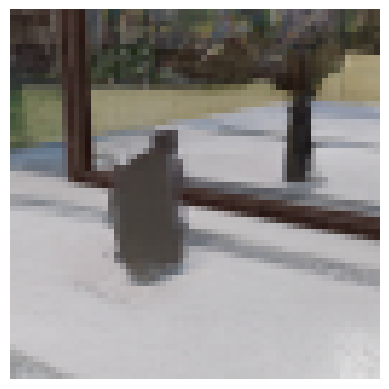

In [27]:
plt.imshow(samples_np)
plt.axis("off")
# plt.title("Generated Image")
plt.savefig("/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png")
plt.show()


## MLLM Score

In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
# from transformers import AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

# local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct"

# model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#     local_path, torch_dtype="auto", device_map="auto"
# )

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/QVQ-72B-Preview"

mllm_model = Qwen2VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

processor = AutoProcessor.from_pretrained(local_path)

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-04-05 16:46:06.301805: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-05 16:46:06.552116: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743842766.630650  708120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743842766.652792  708120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743842766.854634  708120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [5]:
import re
def evaluate_image(image_path,image_size,model) -> str:
    """
    Evaluates the given image for internal visual consistency and returns a score.
    
    The evaluation is performed by prompting the model with a message asking to rate the image
    from 0 (inconsistent) to 10 (completely harmonious and consistent), following the format:
    "The score is {your_score}. The reason is {your_reason}."
    
    Args:
        image_path (str): The path to the image.
    
    Returns:
        str: The generated output text containing the score and the reason.
    """
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
                {"type": "text", "text": (
                "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
                "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
                "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
                # "What is your score?"
                )},
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to("cuda")

    # Inference: Generation of the output
    generated_ids = model.generate(**inputs, max_new_tokens=9000)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    print("output_text:",output_text)
    pattern = r"The score is (\d+)"
    match = re.search(pattern, output_text[0])
    if match:
        return int(match.group(1))
    else:
        return extract_score_after_final_answer(output_text)

import re

def extract_score_after_final_answer(output_text):
    """
    从给定文本中查找 **Final Answer** 后面出现的第一个数字，并返回其整数值。
    如果未找到，则抛出 ValueError。
    """
    # 若 output_text 是列表，则默认取第一个元素
    if isinstance(output_text, list):
        text_to_search = output_text[0]
    else:
        text_to_search = output_text

    # 正则：匹配 "**Final Answer**" 后，任意字符(含换行)，再遇到数字(\d+)
    pattern = r"\*\*Final Answer\*\*.*?(\d+)"
    match = re.search(pattern, text_to_search, re.DOTALL)

    if match:
        return int(match.group(1))
    else:
        raise ValueError(f"No number found after **Final Answer** in: {text_to_search}")


In [6]:
image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
scores = evaluate_image(image_path,image_size,mllm_model)
print(scores)

output_text: ["The score is 0. The reason is that the reflection in the mirror does not match the object's contour, shape, or spatial alignment. The object appears to be a bottle, but its reflection looks distorted and inconsistent with the actual object's features."]
0


## MLLM Adjust

### Ori 

In [5]:
import random
seed = 12345
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
n = 1  # batch size = 1
quantT = torch.randn(n, vae_embed_dim, dit_input_size, dit_input_size, device=device)

sampling_kwargs_lat = dict(
    model=model,
    latents=quantT,
    y=torch.randint(0, num_classes, (n,), device=device),
    num_steps=num_steps,
    heun=False,
    cfg_scale=cfg_scale,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes
)

with torch.no_grad():
    quant = euler_sampler(**sampling_kwargs_lat).to(torch.float32)
    quant = quant * vq_std + vq_mean  # 反归一化


In [13]:
with torch.no_grad():

    # 准备 decoder 的初始噪声
    xT = torch.randn(n, 3, resolution, resolution, device=quant.device)

    B, C, H, W = quant.shape  
    quant = quant.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=vae.decoder,
        latents=xT,
        y=quant,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    samples = euler_sampler(**sampling_kwargs_img).to(torch.float32)

samples = torch.clamp((samples + 1) / 2, 0, 1)  # [-1, 1] → [0, 1]
samples_np = samples[0].permute(1, 2, 0).cpu().numpy()

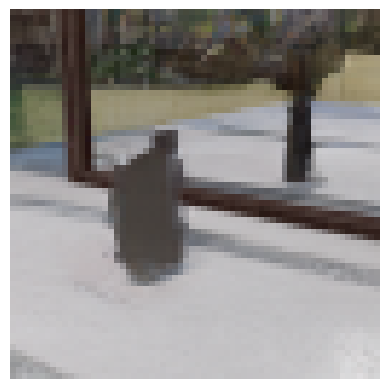

In [14]:
plt.imshow(samples_np)
plt.axis("off")
# plt.title("Generated Image")
plt.show()

In [12]:
def euler_sampler_diff(
        model,
        latents,
        y,
        num_steps=20,
        heun=False,
        cfg_scale=1.0,
        guidance_low=0.0,
        guidance_high=1.0,
        path_type="linear",
        num_classes=1000,
        return_intermediates=False  # 新增参数，决定是否返回中间结果
    ):
    xts = []
    x0_preds = []

    if cfg_scale > 1.0:
        y_null = torch.tensor([num_classes] * y.size(0), device=y.device)
    _dtype = latents.dtype    
    t_steps = torch.linspace(1, 0, num_steps+1, dtype=torch.float64)
    x_next = latents.to(torch.float64)
    device = x_next.device

    with torch.no_grad():
        for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
            x_cur = x_next
            if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                model_input = torch.cat([x_cur] * 2, dim=0)
                y_cur = torch.cat([y, y_null], dim=0)
            else:
                model_input = x_cur
                y_cur = y            
            kwargs = dict(y=y_cur)
            time_input = torch.ones(model_input.size(0)).to(device=device, dtype=torch.float64) * t_cur
            # print("model_input:",model_input.shape)
            # 当前步的 d(x)
            d_cur = model(
                model_input.to(dtype=_dtype), time_input.to(dtype=_dtype), **kwargs
            )[0].to(torch.float64)

            if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                d_cur_cond, d_cur_uncond = d_cur.chunk(2)
                d_cur = d_cur_uncond + cfg_scale * (d_cur_cond - d_cur_uncond)

            # 当前的 x_0 预测值
            x0_pred = x_cur - t_cur * d_cur
            if return_intermediates:
                xts.append(x_cur.detach().clone().to(torch.float32))
                x0_preds.append(x0_pred.detach().clone().to(torch.float32))

            x_next = x_cur + (t_next - t_cur) * d_cur

            # Heun 修正项
            if heun and (i < num_steps - 1):
                if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                    model_input = torch.cat([x_next] * 2)
                    y_cur = torch.cat([y, y_null], dim=0)
                else:
                    model_input = x_next
                    y_cur = y
                kwargs = dict(y=y_cur)
                time_input = torch.ones(model_input.size(0)).to(
                    device=model_input.device, dtype=torch.float64
                ) * t_next
                d_prime = model(
                    model_input.to(dtype=_dtype), time_input.to(dtype=_dtype), **kwargs
                )[0].to(torch.float64)
                if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                    d_prime_cond, d_prime_uncond = d_prime.chunk(2)
                    d_prime = d_prime_uncond + cfg_scale * (d_prime_cond - d_prime_uncond)
                x_next = x_cur + (t_next - t_cur) * (0.5 * d_cur + 0.5 * d_prime)

    if return_intermediates:
        return x_next, xts, x0_preds
    return x_next

In [13]:
import random
seed = 12345
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
n = 1  # batch size = 1
quantT = torch.randn(n, vae_embed_dim, dit_input_size, dit_input_size, device=device)

sampling_kwargs_lat = dict(
    model=model,
    latents=quantT,
    y=torch.randint(0, num_classes, (n,), device=device),
    num_steps=num_steps,
    heun=False,
    cfg_scale=cfg_scale,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes
)

with torch.no_grad():
    quant = euler_sampler(**sampling_kwargs_lat).to(torch.float32)
    quant = quant * vq_std + vq_mean  # 反归一化


In [14]:
xT = torch.randn(n, 3, resolution, resolution, device=quant.device)
B, C, H, W = quant.shape  
quant = quant.view(B, C, H * W).permute(0, 2, 1) 
samples, xts, x0_preds = euler_sampler_diff(
    model=vae.decoder,
    latents=xT,
    y=quant,
    num_steps=50,
    heun=False,
    cfg_scale=1,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes,
    return_intermediates=True
)


In [15]:
xts[0].shape

torch.Size([1, 3, 64, 64])

In [49]:
x0_preds[0].shape

torch.Size([1, 3, 64, 64])

In [39]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import os

os.makedirs("/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/sampling_steps", exist_ok=True)

for i, (xt, x0_pred) in enumerate(zip(xts, x0_preds)):
    # 只画第一个 batch 样本
    xt_img = TF.to_pil_image(torch.clamp((xt[0] + 1) / 2, 0, 1))
    x0_img = TF.to_pil_image(torch.clamp((x0_pred[0] + 1) / 2, 0, 1))

    fig, axs = plt.subplots(1, 2, figsize=(4, 2))
    axs[0].imshow(xt_img)
    axs[0].set_title(f"x_t @ step {i}")
    axs[0].axis('off')
    axs[1].imshow(x0_img)
    axs[1].set_title(f"x_0 pred")
    axs[1].axis('off')
    fig.tight_layout()
    fig.savefig(f"/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/sampling_steps/step_{i:02d}.png")
    plt.close(fig)


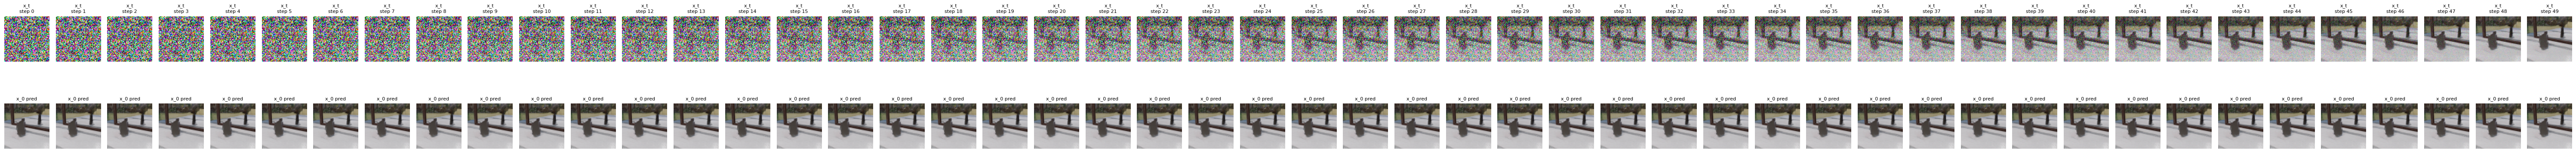

In [16]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# 图像个数
num_steps = len(xts)
fig, axs = plt.subplots(2, num_steps, figsize=(num_steps * 1.2, 2.5 * 2))

for i in range(num_steps):
    xt_img = TF.to_pil_image(torch.clamp((xts[i][0] + 1) / 2, 0, 1))
    x0_img = TF.to_pil_image(torch.clamp((x0_preds[i][0] + 1) / 2, 0, 1))
    
    axs[0, i].imshow(xt_img)
    axs[0, i].set_title(f"x_t\nstep {i}", fontsize=8)
    axs[0, i].axis('off')

    axs[1, i].imshow(x0_img)
    axs[1, i].set_title("x_0 pred", fontsize=8)
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()


In [48]:
from PIL import Image
import torchvision.transforms.functional as TF
import os

# 输出目录
save_dir = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/sampling_steps"
os.makedirs(save_dir, exist_ok=True)

xt_frames = []
x0_frames = []

for xt, x0_pred in zip(xts, x0_preds):
    # 只处理第一个 batch 样本
    xt_img = TF.to_pil_image(torch.clamp((xt[0] + 1) / 2, 0, 1))
    x0_img = TF.to_pil_image(torch.clamp((x0_pred[0] + 1) / 2, 0, 1))
    xt_frames.append(xt_img)
    x0_frames.append(x0_img)

# 保存 GIF 动图
xt_gif_path = os.path.join(save_dir, "xt_animation.gif")
x0_gif_path = os.path.join(save_dir, "x0_pred_animation.gif")

xt_frames[0].save(
    xt_gif_path,
    save_all=True,
    append_images=xt_frames[1:],
    duration=200,
    loop=0
)

x0_frames[0].save(
    x0_gif_path,
    save_all=True,
    append_images=x0_frames[1:],
    duration=200,
    loop=0
)


# Qwen- guidance

In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
# from transformers import AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-72B-Instruct"

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

# local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/QVQ-72B-Preview"

# mllm_model = Qwen2VLForConditionalGeneration.from_pretrained(
#     local_path, torch_dtype="auto", device_map="auto"
# )

processor = AutoProcessor.from_pretrained(local_path)

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-04-06 12:29:00.688091: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 12:29:00.701354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743913740.716995  833310 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743913740.721581  833310 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743913740.733776  833310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [29]:
# # Normalized
# import torch
# import torch.nn as nn
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.ndimage import zoom
# import re
# from transformers import AutoTokenizer

# image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
# image_size = 256
# messages = [
#     {
#         "role": "user",
#         "content": [
#             {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
#             {"type": "text", "text": (
#             "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
#             "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
#             "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
#             )},
#         ],
#     }
# ]

# # Preparation for inference
# text = processor.apply_chat_template(
#     messages, tokenize=False, add_generation_prompt=True
# )
# image_inputs, video_inputs = process_vision_info(messages)
# inputs = processor(
#     text=[text],
#     images=image_inputs,
#     videos=video_inputs,
#     padding=True,
#     return_tensors="pt",
# )
# inputs = inputs.to("cuda")


In [7]:
# for name, module in mllm_model.named_modules():
#     if 'vision' in name.lower() or 'image' in name.lower() or 'patch' in name.lower():
#         print(f"{name} : {module.__class__.__name__}")

# print("===== Visual Backbone Parameters =====")
# for name, module in mllm_model.named_modules():
#     if hasattr(module, 'patch_size'):
#         print(f"{name}.patch_size = {module.patch_size}")
#     if hasattr(module, 'image_size'):
#         print(f"{name}.image_size = {module.image_size}")
#     if hasattr(module, 'embed_dim'):
#         print(f"{name}.embed_dim = {module.embed_dim}")

# for name, module in mllm_model.named_modules():
#     if 'projector' in name:
#         print(f"{name}: {module}")
# print(processor)

### Pure grads

In [38]:
# Normalized 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import re
from transformers import AutoTokenizer

image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            # "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
            "What is your score?"
            )},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


# ✅ 4. 启用梯度计算，重新 forward 计算 logits
inputs['pixel_values'].requires_grad = True  # 重新启用梯度

In [43]:
# 拿最后一个 token 的预测 ID
zero_logit = mllm_model(**inputs, output_hidden_states=False).logits[:, -1, :]
last_token_id = zero_logit.argmax(dim=-1)  # shape: [B]

# 解码成 token（字符串）
last_token_str = processor.tokenizer.batch_decode(last_token_id.unsqueeze(0))
print("📌 最后一个 token 是：", last_token_str[0])


📌 最后一个 token 是： Score


In [48]:
# Normalized 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import re
from transformers import AutoTokenizer

image_path = "/cpfs04/user/hanyujin/rule-gen/datasets/mirrors_train/left/00002.png"
# "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            # "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
            "What is your score?"
            )},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


# ✅ 4. 启用梯度计算，重新 forward 计算 logits
inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# 启用梯度计算，重新获取 logits 计算梯度
# input_len = inputs['input_ids'].shape[1]
# logits = mllm_model(**inputs, output_hidden_states=False).logits
# zero_logit = logits[:, input_len, :]  # 取第一个生成 token 的 logits
zero_logit = mllm_model(**inputs, output_hidden_states=False).logits[:, -1, :]
true_class = torch.argmax(zero_logit, dim=1)

# 计算 CrossEntropy Loss
criterion = nn.CrossEntropyLoss()
loss = -criterion(zero_logit, true_class)

# 计算 grads
grads = torch.autograd.grad(loss, inputs['pixel_values'], retain_graph=True)[0]
print(f"Grads shape: {grads.shape}")  # 应该是 [324, 1176] 或其他

# 重新 reshape grads
token_grid_size = int(np.sqrt(grads.shape[0]))  # 计算 token grid 的大小
grads = grads[:token_grid_size**2, :].view(token_grid_size, token_grid_size, -1)
print(f"Reshaped grads shape: {grads.shape}")  # [18, 18, 1176]

# 计算 grads 的范数
grad_norm = torch.norm(grads, dim=-1).detach().cpu().numpy()
print(f"Grad norm shape: {grad_norm.shape}")  # [18, 18]

## General
general_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
                "Write a general description of the image."
            )},
        ],
    }
]

# Preparation for inference
general_text = processor.apply_chat_template(
    general_messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(general_messages)
general_inputs = processor(
    text=[general_text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
general_inputs = general_inputs.to("cuda")

general_inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# 启用梯度计算，重新获取 logits 计算梯度
# general_input_len = general_inputs['input_ids'].shape[1]
# general_logits = mllm_model(**general_inputs, output_hidden_states=False).logits
# general_zero_logit = general_logits[:, general_input_len, :]  # 取第一个生成 token 的 logits
general_zero_logit = mllm_model(**general_inputs, output_hidden_states=False).logits[:, -1, :]
general_true_class = torch.argmax(general_zero_logit, dim=1)
print("general_true_class:",general_true_class)
general_loss = -criterion(general_zero_logit, general_true_class)

# 计算 grads
general_grads = torch.autograd.grad(general_loss, general_inputs['pixel_values'], retain_graph=True)[0]
print(f"Grads shape: {general_grads.shape}")  # 应该是 [324, 1176] 或其他

# 重新 reshape grads
general_token_grid_size = int(np.sqrt(general_grads.shape[0]))  # 计算 token grid 的大小
general_grads = general_grads[:general_token_grid_size**2, :].view(general_token_grid_size, general_token_grid_size, -1)
print(f"General Reshaped grads shape: {general_grads.shape}")  # [18, 18, 1176]

# 计算 grads 的范数
general_grad_norm = torch.norm(general_grads, dim=-1).detach().cpu().numpy()
print(f"General Grad norm shape: {general_grad_norm.shape}")  # [18, 18]

grad_norm_norm = grad_norm / general_grad_norm

Grads shape: torch.Size([100, 1176])
Reshaped grads shape: torch.Size([10, 10, 1176])
Grad norm shape: (10, 10)
general_true_class: tensor([785], device='cuda:0')
Grads shape: torch.Size([100, 1176])
General Reshaped grads shape: torch.Size([10, 10, 1176])
General Grad norm shape: (10, 10)


In [49]:
def visualize_token_grads_from_heatmap(grad_norm_map, image_size=(64, 64), title="Token Grad Ratio Heatmap"):
    """
    grad_norm_map: torch.Tensor or np.ndarray of shape [H, W]
    This function assumes you have already computed the token-level heatmap (e.g., grad_norm / general_grad_norm)
    and just want to upsample + visualize it.
    """
    import torch
    import torch.nn.functional as F
    import matplotlib.pyplot as plt

    # Ensure tensor
    if isinstance(grad_norm_map, np.ndarray):
        grad_norm_map = torch.from_numpy(grad_norm_map)

    grad_norm_map = grad_norm_map.float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

    # Interpolate to image size
    grad_interp = F.interpolate(grad_norm_map, size=image_size, mode='bilinear', align_corners=False)

    # 可视化
    plt.imshow(grad_interp[0, 0].cpu().numpy(), cmap='viridis')
    plt.title(title)
    plt.colorbar()
    plt.axis('off')
    plt.show()

    return grad_interp  # shape: [1, 1, H, W]


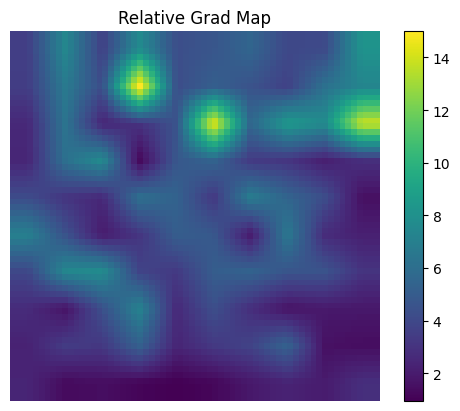

tensor([[[[3.5684, 3.5684, 3.5684,  ..., 8.1643, 8.1643, 8.1643],
          [3.5684, 3.5684, 3.5684,  ..., 8.1643, 8.1643, 8.1643],
          [3.5684, 3.5684, 3.5684,  ..., 8.1643, 8.1643, 8.1643],
          ...,
          [2.3882, 2.3882, 2.3882,  ..., 2.8400, 2.8400, 2.8400],
          [2.3882, 2.3882, 2.3882,  ..., 2.8400, 2.8400, 2.8400],
          [2.3882, 2.3882, 2.3882,  ..., 2.8400, 2.8400, 2.8400]]]])

In [50]:
visualize_token_grads_from_heatmap(grad_norm_norm, image_size=(64, 64), title="Relative Grad Map")

## Attned-grads

In [133]:
# Normalized 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import re
from transformers import AutoTokenizer

image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
            )},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


# ✅ 4. 启用梯度计算，重新 forward 计算 logits
inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# 启用梯度计算，重新获取 logits 计算梯度
zero_logit = mllm_model(**inputs, output_hidden_states=False).logits[:, -1, :]
true_class = torch.argmax(zero_logit, dim=1)

# 计算 CrossEntropy Loss
criterion = nn.CrossEntropyLoss()
loss = -criterion(zero_logit, true_class)

# 计算 grads
grads = torch.autograd.grad(loss, inputs['pixel_values'], retain_graph=True)[0]
print(f"Grads shape: {grads.shape}")  # 应该是 [324, 1176] 或其他

# 重新 reshape grads
# token_grid_size = int(np.sqrt(grads.shape[0]))  # 计算 token grid 的大小
# grads = grads[:token_grid_size**2, :].view(token_grid_size, token_grid_size, -1)
# print(f"Reshaped grads shape: {grads.shape}")  # [18, 18, 1176]

# # 计算 grads 的范数
# grad_norm = torch.norm(grads, dim=-1).detach().cpu().numpy()
# print(f"Grad norm shape: {grad_norm.shape}")  # [18, 18]

# ## General
# general_messages = [
#     {
#         "role": "user",
#         "content": [
#             {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
#             {"type": "text", "text": (
#                 "Write a general description of the image."
#             )},
#         ],
#     }
# ]

# # Preparation for inference
# general_text = processor.apply_chat_template(
#     general_messages, tokenize=False, add_generation_prompt=True
# )
# image_inputs, video_inputs = process_vision_info(general_messages)
# general_inputs = processor(
#     text=[general_text],
#     images=image_inputs,
#     videos=video_inputs,
#     padding=True,
#     return_tensors="pt",
# )
# general_inputs = general_inputs.to("cuda")

# general_inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# # 启用梯度计算，重新获取 logits 计算梯度
# general_zero_logit = mllm_model(**general_inputs, output_hidden_states=False).logits[:, -1, :]
# general_true_class = torch.argmax(general_zero_logit, dim=1)
# print("general_true_class:",general_true_class)
# general_loss = -criterion(general_zero_logit, general_true_class)

# # 计算 grads
# general_grads = torch.autograd.grad(general_loss, general_inputs['pixel_values'], retain_graph=True)[0]
# print(f"Grads shape: {general_grads.shape}")  # 应该是 [324, 1176] 或其他

# # 重新 reshape grads
# general_token_grid_size = int(np.sqrt(general_grads.shape[0]))  # 计算 token grid 的大小
# general_grads = general_grads[:general_token_grid_size**2, :].view(general_token_grid_size, general_token_grid_size, -1)
# print(f"General Reshaped grads shape: {general_grads.shape}")  # [18, 18, 1176]

# # 计算 grads 的范数
# general_grad_norm = torch.norm(general_grads, dim=-1).detach().cpu().numpy()
# print(f"General Grad norm shape: {general_grad_norm.shape}")  # [18, 18]

# grad_norm_norm = grad_norm / general_grad_norm

Grads shape: torch.Size([100, 1176])


In [137]:
outputs = mllm_model(**inputs, output_attentions=True)
CE = nn.CrossEntropyLoss()
zero_logit = outputs.logits[:, -1, :]  # 只取最后一个 token 的输出
true_class = torch.argmax(zero_logit, dim=1)
loss = -CE(zero_logit, true_class)

Qwen2VLModel is using Qwen2VLSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [139]:
import torch.nn.functional as F
ATT_LAYER = 14
attention = outputs.attentions[ATT_LAYER]
grads = torch.autograd.grad(loss, attention, retain_graph=True)
grad_att = attention * F.relu(grads[0])

In [141]:
grad_att.shape

torch.Size([1, 64, 213, 213])

In [ ]:
att_map = grad_att[0, :, -1, pos:pos+NUM_IMG_TOKENS].mean(dim=0).to(torch.float32).detach().cpu().numpy().reshape(NUM_PATCHES, NUM_PATCHES)

### Score head

In [61]:
def visualize_token_grads(grads, image_size=(64, 64), title="Token Grad Heatmap"):
    """
    grads: [N_tokens, D]
    """
    import torch.nn.functional as F
    import matplotlib.pyplot as plt

    num_tokens = grads.shape[0]
    token_grid = int(np.sqrt(num_tokens))
    
    # 自动截断到最小正方形
    usable_tokens = token_grid * token_grid
    grads = grads[:usable_tokens]  # 忽略最后几个 token
    grads = grads.view(token_grid, token_grid, -1)

    grad_norm = grads.norm(dim=-1).unsqueeze(0).unsqueeze(0)  # shape [1, 1, H, W]
    grad_interp = F.interpolate(grad_norm, size=image_size, mode='bilinear', align_corners=False)

    # 可视化
    plt.imshow(grad_interp[0, 0].cpu().detach().numpy(), cmap='viridis')
    plt.title(title)
    plt.colorbar()
    plt.axis('off')
    plt.show()

    return grad_interp  # shape: [1, 1, H, W]

In [111]:
# Normalized
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import re
from transformers import AutoTokenizer

image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
            )},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


# Normalized 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import re
from transformers import AutoTokenizer

image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
            )},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


## General
general_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
                "Write a general description of the image."
            )},
        ],
    }
]

# Preparation for inference
general_text = processor.apply_chat_template(
    general_messages, tokenize=False, add_generation_prompt=True
)
# ✅ 正确使用 general_messages
general_image_inputs, general_video_inputs = process_vision_info(general_messages)

general_inputs = processor(
    text=[general_text],
    images=general_image_inputs,
    videos=general_video_inputs,
    padding=True,
    return_tensors="pt",
)
general_inputs = general_inputs.to("cuda")

In [112]:
class MirrorScoreHead(nn.Module):
    def __init__(self, input_dim=1176):
        super().__init__()
        self.score_head = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )

    def forward(self, image_tokens):  # [B, N, D]
        assert image_tokens.ndim == 3  # [B, N, D]
        pooled = image_tokens.mean(dim=1)  # [B, D]
        return self.score_head(pooled).squeeze(-1)  # [B]


In [129]:
# Task-specific gradient (score = 0)
# 假设 image_tokens 是 [100, 1176]
image_tokens = inputs['pixel_values']
image_tokens.requires_grad_()
image_tokens = image_tokens.unsqueeze(0)  # shape: [1, 100, 1176]

# Forward
score_model = MirrorScoreHead(input_dim=image_tokens.shape[-1]).to(image_tokens.device)
pred_score = score_model(image_tokens)  # shape: [1]
print("Predicted score (logit):", pred_score.item())

# 假设你想引导模型输出为 0（表示不合理）
target_label = torch.tensor([0.0], device=image_tokens.device)

# Binary Cross-Entropy Loss (logits version)
loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(pred_score, target_label)

# 计算梯度
grads = torch.autograd.grad(loss, image_tokens)[0]  # shape: [1, 100, 1176]


# # General gradient (image description)
# general_image_tokens = general_inputs['pixel_values']
# general_image_tokens.requires_grad_()
# general_image_tokens = general_image_tokens.unsqueeze(0)
# general_score = score_model(general_image_tokens)
# print("general_score:",general_score)
# general_loss = nn.MSELoss()(general_score, torch.tensor([0.5], device=general_image_tokens.device))  # 中立
# general_grads = torch.autograd.grad(general_loss, general_image_tokens)[0]  # [1, N, D]

# # Normalize
# task_grad_norm = task_grads.norm(dim=-1)[0]       # shape: [N]
# general_grad_norm = general_grads.norm(dim=-1)[0] # shape: [N]
# relative_importance = task_grad_norm / (general_grad_norm + 1e-6)  # [N]


Predicted score (logit): -0.21426080167293549


In [131]:
image_tokens = inputs['pixel_values']
image_tokens.requires_grad_()
image_tokens = image_tokens.unsqueeze(0)
score_model = MirrorScoreHead(input_dim=image_tokens.shape[-1]).to(image_tokens.device)
pred_score = score_model(image_tokens)
print("print(pred_score):",pred_score)
loss = nn.MSELoss()(pred_score, torch.tensor([0.0], device=image_tokens.device))
print("loss",loss)

print(pred_score): tensor([0.1856], device='cuda:0', grad_fn=<SqueezeBackward1>)
loss tensor(0.0345, device='cuda:0', grad_fn=<MseLossBackward0>)


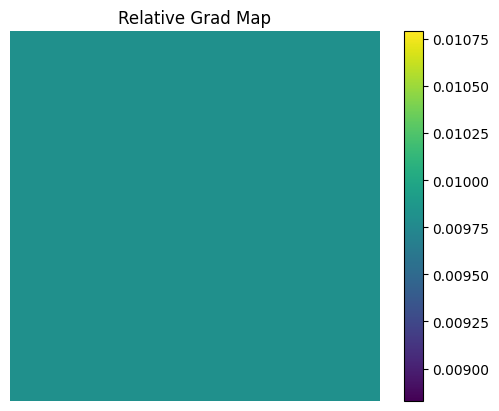

tensor([[[[0.0098, 0.0098, 0.0098,  ..., 0.0098, 0.0098, 0.0098],
          [0.0098, 0.0098, 0.0098,  ..., 0.0098, 0.0098, 0.0098],
          [0.0098, 0.0098, 0.0098,  ..., 0.0098, 0.0098, 0.0098],
          ...,
          [0.0098, 0.0098, 0.0098,  ..., 0.0098, 0.0098, 0.0098],
          [0.0098, 0.0098, 0.0098,  ..., 0.0098, 0.0098, 0.0098],
          [0.0098, 0.0098, 0.0098,  ..., 0.0098, 0.0098, 0.0098]]]],
       device='cuda:0')

In [132]:
visualize_token_grads(grads, image_size=(64, 64), title="Relative Grad Map")

(100, 100)


(-0.5, 99.5, 99.5, -0.5)

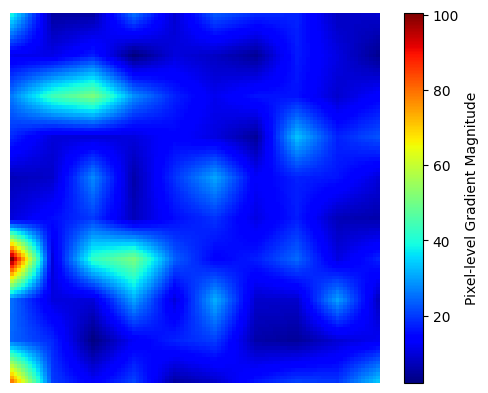

In [11]:
print(grad_image.shape)
plt.imshow(grad_image, cmap='jet')
plt.colorbar(label="Pixel-level Gradient Magnitude")
plt.axis('off')

(100, 100)


(-0.5, 99.5, 99.5, -0.5)

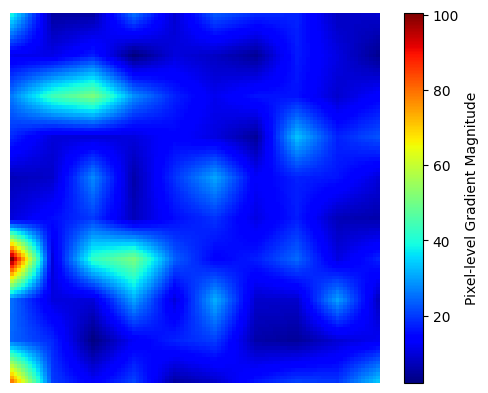

In [4]:
print(grad_image.shape)
plt.imshow(grad_image, cmap='jet')
plt.colorbar(label="Pixel-level Gradient Magnitude")
plt.axis('off')

# Llava

In [1]:
import requests
from PIL import Image
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

model_id = "/nas/shared/CausaLLMs/MLLM_Models/llava-1.5-13b-hf"
model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    torch_dtype=torch.float16, 
    low_cpu_mem_usage=True, 
).to(0)

processor = AutoProcessor.from_pretrained(model_id)

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-06 12:04:05.416043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 12:04:05.625569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743912245.703101  775062 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743912245.725037  775062 cuda_blas.cc:1407] Un

KeyboardInterrupt: 

In [ ]:
# # Normalized
# import torch
# import torch.nn as nn
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.ndimage import zoom
# import re
# from transformers import AutoTokenizer

# image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
# image_size = 256
# messages = [
#     {
#         "role": "user",
#         "content": [
#             {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
#             {"type": "text", "text": (
#             "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
#             "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
#             "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
#             )},
#         ],
#     }
# ]

# # Preparation for inference
# text = processor.apply_chat_template(
#     messages, tokenize=False, add_generation_prompt=True
# )
# image_inputs, video_inputs = process_vision_info(messages)
# inputs = processor(
#     text=[text],
#     images=image_inputs,
#     videos=video_inputs,
#     padding=True,
#     return_tensors="pt",
# )
# inputs = inputs.to("cuda")


In [ ]:
# Define a chat history and use `apply_chat_template` to get correctly formatted prompt
# Each value in "content" has to be a list of dicts with types ("text", "image") 
conversation = [
    {

      "role": "user",
      "content": [
          {"type": "text", "text": "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."},
          {"type": "image"},
        ],
    },
]
prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
raw_image = Image.open(image_path)
inputs = processor(images=raw_image, text=prompt, return_tensors='pt').to(0, torch.float16)

output = model.generate(**inputs, max_new_tokens=200, do_sample=False)
print(processor.decode(output[0][2:], skip_special_tokens=True))

# Qwen-2.5-VL

In [1]:
import math 

def calculate_plt_size(attention_layer_num):    
    num_layers = attention_layer_num
    cols = math.ceil(math.sqrt(num_layers))  
    rows = math.ceil(num_layers / cols)     
    return rows, cols

In [1]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
import torch
import matplotlib.pyplot as plt
from qwen_vl_utils import process_vision_info

device = 'cuda'
model_path = '/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct'

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
                model_path,
                torch_dtype=torch.bfloat16,
                attn_implementation="eager",
                device_map='auto',
            ).eval()
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True, padding_side='left', use_fast=True)


/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2025-04-06 12:16:55.732406: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 12:16:55.746139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743913015.761995 3257208 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743913015.766609 3257208 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743913015.779072 3257208 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
question = "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies. Please answer in the the format: The score is {your_score}. The reason is {your_reason}."

messages_query = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,
            },
            {"type": "text", "text": f"{question} Answer:"},
        ],
    }
]

image_inputs, _ = process_vision_info(messages_query)

text_query = processor.apply_chat_template(
    messages_query,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text_query],
    images=image_inputs,
    padding=True,
    return_tensors="pt",
).to(device)

messages_general = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,
            },
            {"type": "text", "text": "Write a general description of the image. Answer:"},
        ],
    }
]

text_general = processor.apply_chat_template(
    messages_general,
    tokenize=False,
    add_generation_prompt=True
)

general_inputs = processor(
    text=[text_general],
    images=image_inputs,
    padding=True,
    return_tensors="pt",
).to(device)


In [4]:
image_inputs_aux = processor.image_processor(images=image_inputs)
output_shape = image_inputs_aux["image_grid_thw"].numpy().squeeze(0)[1:]/2
output_shape = output_shape.astype(int)

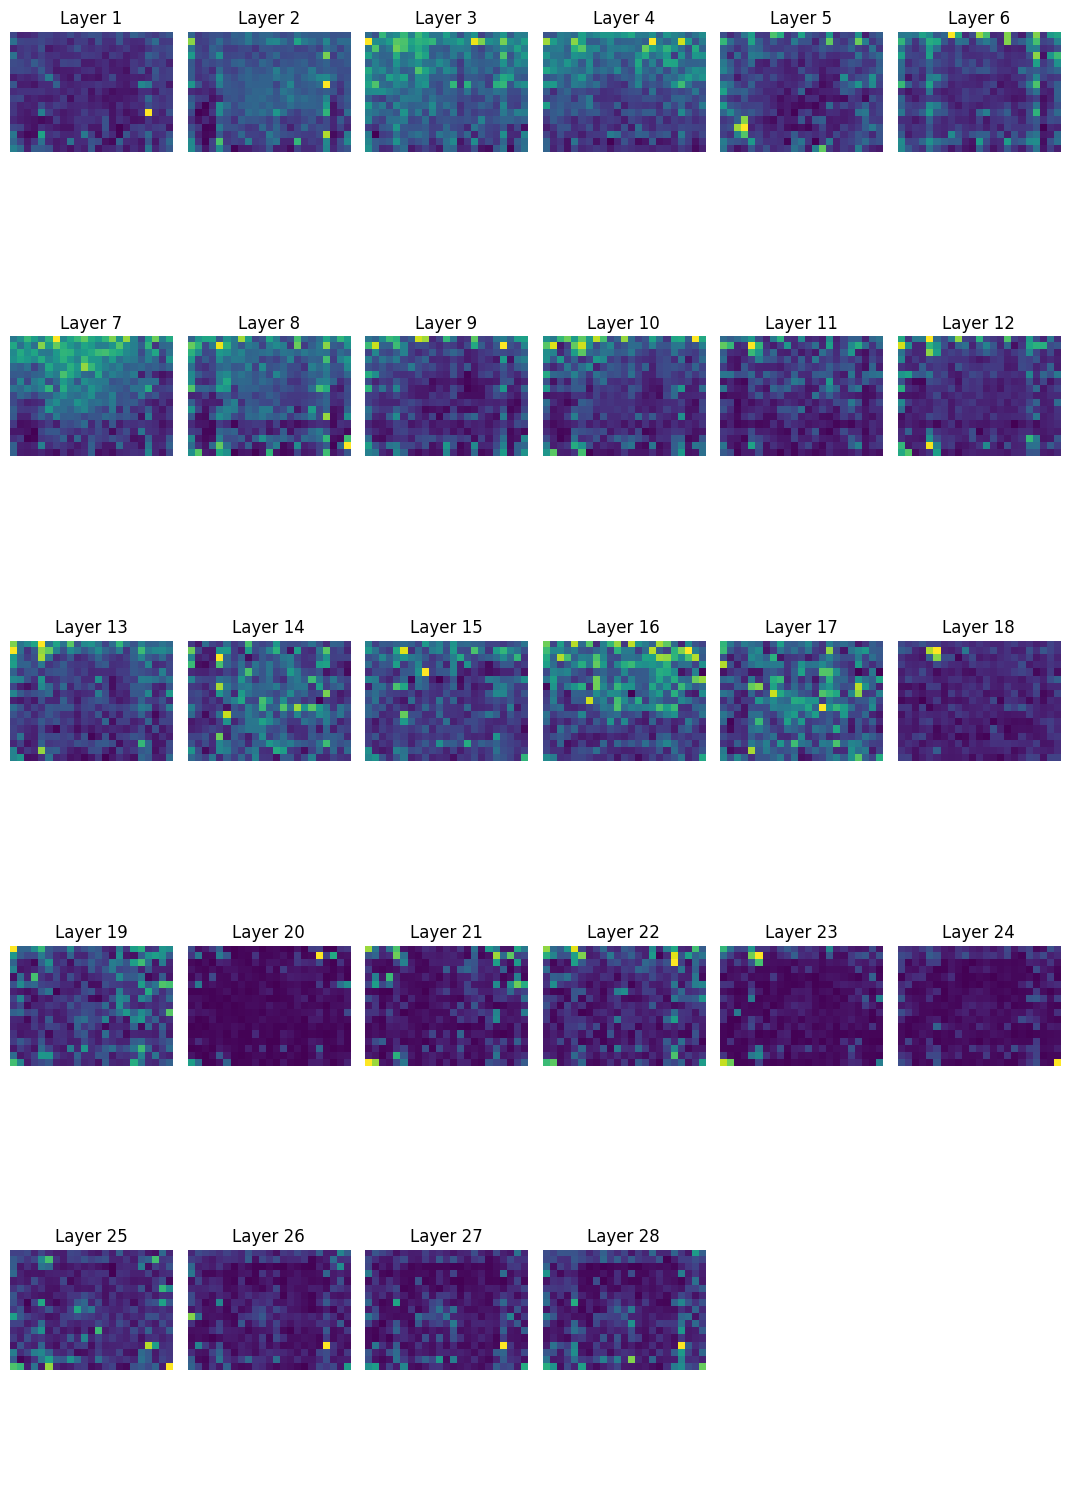

In [5]:
with torch.no_grad():
    vision_start_token_id = processor.tokenizer.convert_tokens_to_ids('<|vision_start|>')
    vision_end_token_id = processor.tokenizer.convert_tokens_to_ids('<|vision_end|>')    
    pos = inputs['input_ids'].tolist()[0].index(vision_start_token_id) + 1
    pos_end = inputs['input_ids'].tolist()[0].index(vision_end_token_id)

    output = mllm_model(**inputs, output_attentions=True)
    general_output = mllm_model(**general_inputs, output_attentions=True)
    rows, cols = calculate_plt_size(len(output.attentions))
    fig, axes = plt.subplots(rows, cols, figsize=(10.8, 16))
    for i, ax in enumerate(axes.flatten()):
        if i < len(output.attentions): 
            att = output.attentions[i][0, :, -1, pos:pos_end].mean(dim=0)
            att = att.to(torch.float32).detach().cpu().numpy()

            general_att = general_output.attentions[i][0, :, -1, pos:pos_end].mean(dim=0)
            general_att = general_att.to(torch.float32).detach().cpu().numpy()

            att = att / general_att

            ax.imshow(att.reshape(output_shape), cmap="viridis", interpolation="nearest")
            ax.set_title(f"Layer {i+1}")
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()    
    plt.show()    

In [2]:
# Normalized 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import re
from transformers import AutoTokenizer

image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies."
            "Please answer in the the format: The score is {your_score}. The reason is {your_reason}."
            )},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


# ✅ 4. 启用梯度计算，重新 forward 计算 logits
inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# 启用梯度计算，重新获取 logits 计算梯度
zero_logit = mllm_model(**inputs, output_hidden_states=False).logits[:, -1, :]
true_class = torch.argmax(zero_logit, dim=1)

# 计算 CrossEntropy Loss
criterion = nn.CrossEntropyLoss()
loss = -criterion(zero_logit, true_class)

# 计算 grads
grads = torch.autograd.grad(loss, inputs['pixel_values'], retain_graph=True)[0]
print(f"Grads shape: {grads.shape}")  # 应该是 [324, 1176] 或其他

# 重新 reshape grads
token_grid_size = int(np.sqrt(grads.shape[0]))  # 计算 token grid 的大小
grads = grads[:token_grid_size**2, :].view(token_grid_size, token_grid_size, -1)
print(f"Reshaped grads shape: {grads.shape}")  # [18, 18, 1176]

# 计算 grads 的范数
grad_norm = torch.norm(grads, dim=-1).detach().cpu().numpy()
print(f"Grad norm shape: {grad_norm.shape}")  # [18, 18]

## General
general_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
                "Write a general description of the image."
            )},
        ],
    }
]

# Preparation for inference
general_text = processor.apply_chat_template(
    general_messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(general_messages)
general_inputs = processor(
    text=[general_text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
general_inputs = general_inputs.to("cuda")

general_inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# 启用梯度计算，重新获取 logits 计算梯度
general_zero_logit = mllm_model(**general_inputs, output_hidden_states=False).logits[:, -1, :]
general_true_class = torch.argmax(general_zero_logit, dim=1)
print("general_true_class:",general_true_class)
general_loss = -criterion(general_zero_logit, general_true_class)

# 计算 grads
general_grads = torch.autograd.grad(general_loss, general_inputs['pixel_values'], retain_graph=True)[0]
print(f"Grads shape: {general_grads.shape}")  # 应该是 [324, 1176] 或其他

# 重新 reshape grads
general_token_grid_size = int(np.sqrt(general_grads.shape[0]))  # 计算 token grid 的大小
general_grads = general_grads[:general_token_grid_size**2, :].view(general_token_grid_size, general_token_grid_size, -1)
print(f"General Reshaped grads shape: {general_grads.shape}")  # [18, 18, 1176]

# 计算 grads 的范数
general_grad_norm = torch.norm(general_grads, dim=-1).detach().cpu().numpy()
print(f"General Grad norm shape: {general_grad_norm.shape}")  # [18, 18]

grad_norm_norm = grad_norm / general_grad_norm

Grads shape: torch.Size([100, 1176])
Reshaped grads shape: torch.Size([10, 10, 1176])
Grad norm shape: (10, 10)
general_true_class: tensor([785], device='cuda:0')
Grads shape: torch.Size([100, 1176])
General Reshaped grads shape: torch.Size([10, 10, 1176])
General Grad norm shape: (10, 10)


✅ 图像 token 数量: 25，Patch 网格大小: 5x5


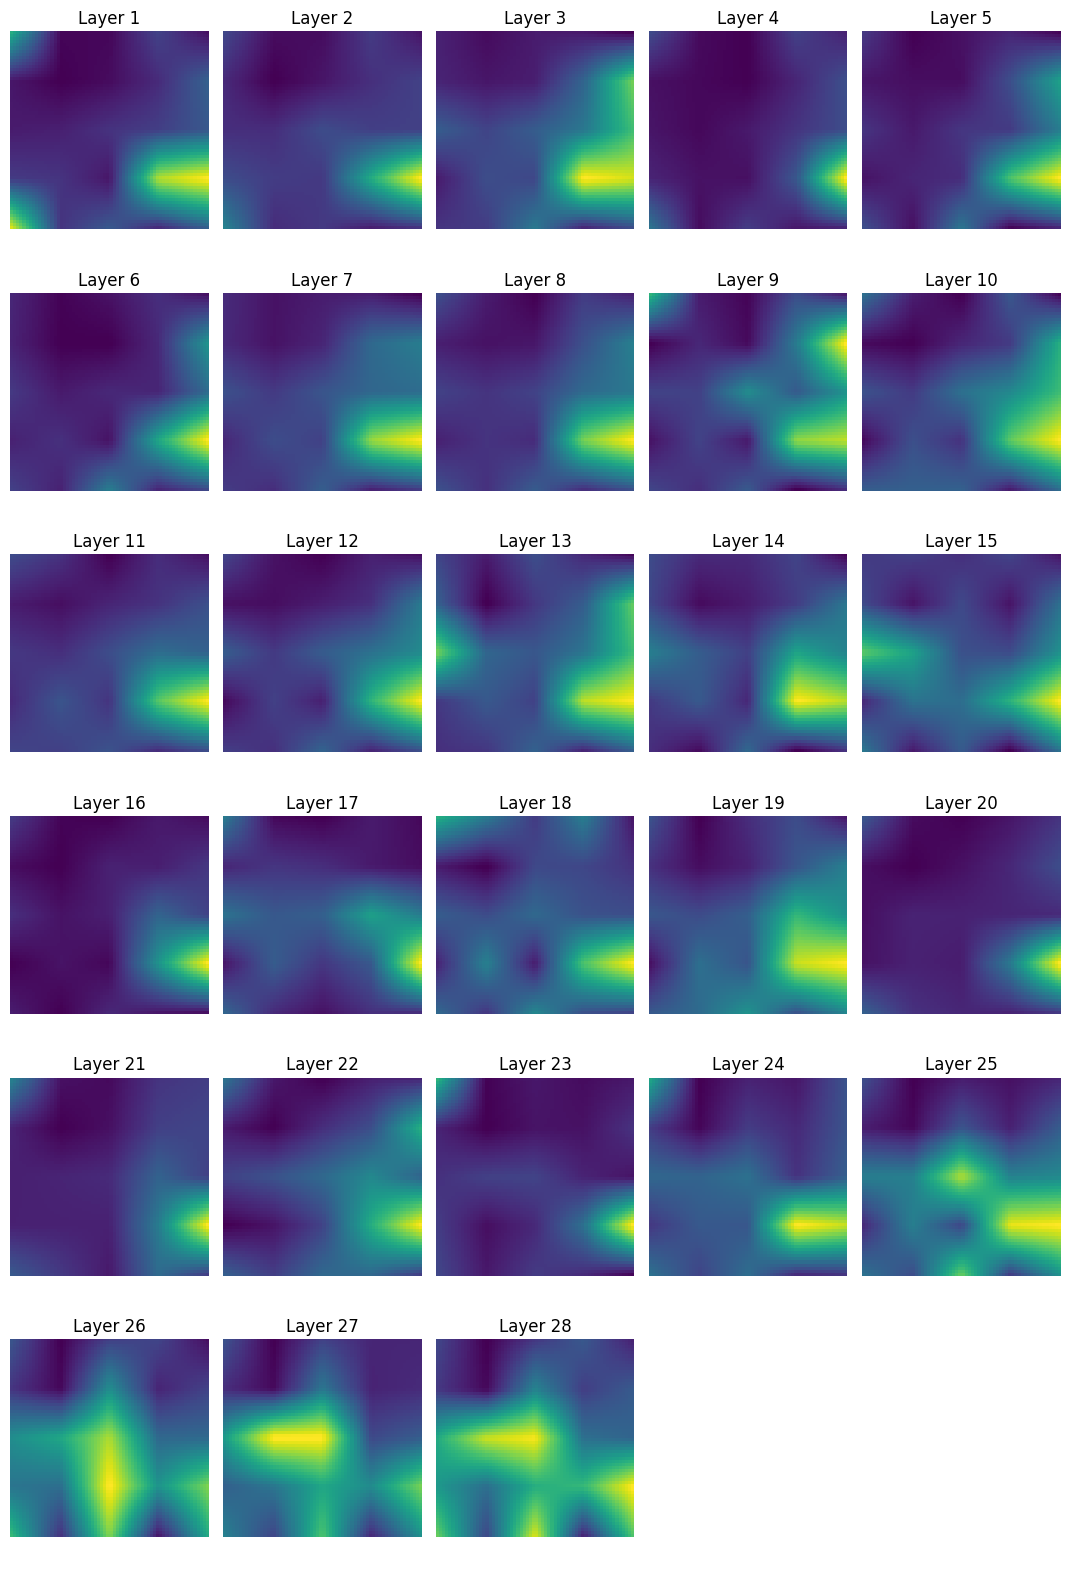

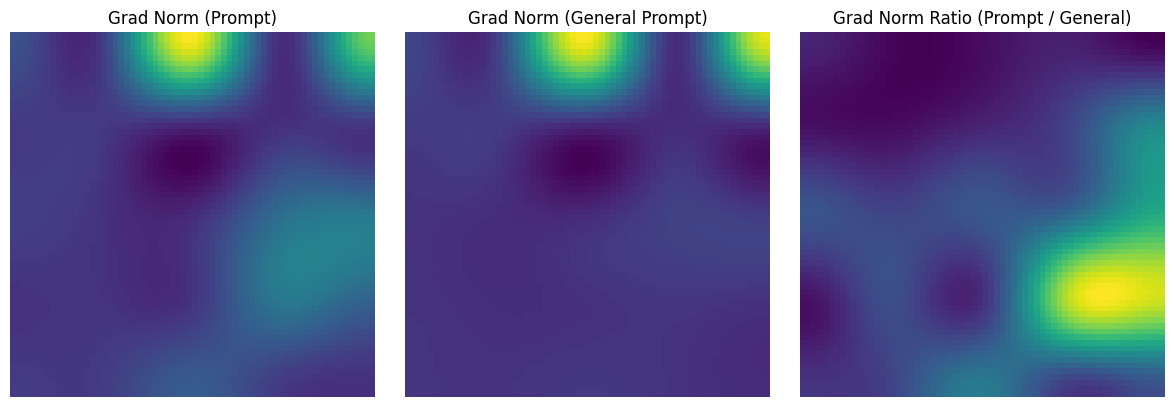

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# 假设你已经准备好以下变量：
# model: Qwen2-VL 模型
# processor: 对应的 processor
# inputs: 带问题 prompt 的输入（包含 pixel_values）
# general_inputs: 泛化 prompt 的输入（包含 pixel_values）
# grad_norm: 对应 inputs 梯度范数 (e.g., [18, 18])
# general_grad_norm: 对应 general_inputs 梯度范数

with torch.no_grad():
    # 图像 token 的位置范围
    vision_start_token_id = processor.tokenizer.convert_tokens_to_ids('<|vision_start|>')
    vision_end_token_id = processor.tokenizer.convert_tokens_to_ids('<|vision_end|>')
    pos = inputs['input_ids'].tolist()[0].index(vision_start_token_id) + 1
    pos_end = inputs['input_ids'].tolist()[0].index(vision_end_token_id)
    num_img_tokens = pos_end - pos
    patch_grid_size = int(np.sqrt(num_img_tokens))

    print(f"✅ 图像 token 数量: {num_img_tokens}，Patch 网格大小: {patch_grid_size}x{patch_grid_size}")

    # 插值梯度范数图，调整为 patch_grid_size 大小
    grad_norm_interp = zoom(grad_norm, (patch_grid_size / grad_norm.shape[0], patch_grid_size / grad_norm.shape[1]), order=1)
    general_grad_norm_interp = zoom(general_grad_norm, (patch_grid_size / general_grad_norm.shape[0], patch_grid_size / general_grad_norm.shape[1]), order=1)
    grad_norm_ratio = grad_norm_interp / (general_grad_norm_interp + 1e-8)

    # 获取模型输出（带 attention）
    output = mllm_model(**inputs, output_attentions=True)
    general_output = mllm_model(**general_inputs, output_attentions=True)

    def calculate_plt_size(n_layers):
        rows = int(np.ceil(np.sqrt(n_layers)))
        cols = int(np.ceil(n_layers / rows))
        return rows, cols

    rows, cols = calculate_plt_size(len(output.attentions))
    fig, axes = plt.subplots(rows, cols, figsize=(10.8, 16))

    for i, ax in enumerate(axes.flatten()):
        if i < len(output.attentions):
            # 当前层的 attention (均值 over heads)，最后一个token到图像tokens的注意力
            att = output.attentions[i][0, :, -1, pos:pos_end].mean(dim=0).to(torch.float32).detach().cpu().numpy()
            general_att = general_output.attentions[i][0, :, -1, pos:pos_end].mean(dim=0).to(torch.float32).detach().cpu().numpy()

            # reshape 成 grid
            att = att.reshape(patch_grid_size, patch_grid_size)
            general_att = general_att.reshape(patch_grid_size, patch_grid_size)

            # attention 比值
            att_ratio = att / (general_att + 1e-8)

            # 融合 attention × 梯度范数比值
            weighted_att = att_ratio * grad_norm_ratio

            # 插值到 64x64
            weighted_att_64 = zoom(weighted_att, (64 / patch_grid_size, 64 / patch_grid_size), order=1)

            # 显示图像
            ax.imshow(weighted_att_64, cmap="viridis", interpolation="nearest")
            ax.set_title(f"Layer {i+1}")
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# ✅ 显示单独的 Grad Norm 图（不乘 attention）

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 输入 prompt 的梯度范数图
axes[0].imshow(zoom(grad_norm_interp, (64 / patch_grid_size, 64 / patch_grid_size)), cmap='viridis')
axes[0].set_title("Grad Norm (Prompt)")
axes[0].axis("off")

# 泛化 prompt 的梯度范数图
axes[1].imshow(zoom(general_grad_norm_interp, (64 / patch_grid_size, 64 / patch_grid_size)), cmap='viridis')
axes[1].set_title("Grad Norm (General Prompt)")
axes[1].axis("off")

# 比值图：Prompt / General
grad_norm_ratio_64 = zoom(grad_norm_ratio, (64 / patch_grid_size, 64 / patch_grid_size))
axes[2].imshow(grad_norm_ratio_64, cmap='viridis')
axes[2].set_title("Grad Norm Ratio (Prompt / General)")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [ ]:

pos = inputs['input_ids'][0].tolist().index(IMAGE_TOKEN_INDEX)

# Compute loss
outputs = model(**inputs, output_attentions=True)
CE = nn.CrossEntropyLoss()
zero_logit = outputs.logits[:, -1, :]
true_class = torch.argmax(zero_logit, dim=1)
loss = -CE(zero_logit, true_class)

# Compute attention and gradients
attention = outputs.attentions[ATT_LAYER]
grads = torch.autograd.grad(loss, attention, retain_graph=True)
grad_att = attention * F.relu(grads[0])

# Compute the attention maps
att_map = grad_att[0, :, -1, pos:pos+NUM_IMG_TOKENS].mean(dim=0).to(torch.float32).detach().cpu().numpy().reshape(NUM_PATCHES, NUM_PATCHES)
    

# Sampling-SMC

In [4]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
# from transformers import AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct"

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

# local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/QVQ-72B-Preview"

# mllm_model = Qwen2VLForConditionalGeneration.from_pretrained(
#     local_path, torch_dtype="auto", device_map="auto"
# )

processor = AutoProcessor.from_pretrained(local_path)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  1.82it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [5]:
import re
import torch
import gc
import re
from qwen_vl_utils import process_vision_info

def mllm_score(image_input, image_size=128, model=None):
    """
    用 Qwen2.5-VL 模型对图片进行评分，返回整数分数 [0,1,2,...,10]
    """
    try:
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image_input,
                        "resized_height": image_size,
                        "resized_width": image_size
                    },
                    {
                        "type": "text",
                        "text": (
                            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. "
                            "Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. "
                            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). "
                            "Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies. "
                            "Please answer in the format: The score is {your_score}. The reason is {your_reason}."
                        )
                    }
                ],
            }
        ]

        # 输入预处理
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        ).to("cuda")

        # 推理
        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=512)
            generated_ids_trimmed = [
                out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
            ]
            output_text = processor.batch_decode(
                generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
            )

        print("output_text:", output_text)

        # 正则提取分数
        pattern1 = r"The score is (\d+)"
        pattern2 = r"\*\*Final Answer\*\*.*?(\d+)"
        for pattern in [pattern1, pattern2]:
            match = re.search(pattern, output_text[0], re.DOTALL)
            if match:
                return int(match.group(1))

        print("⚠️ Could not parse score from model output.")
        return 0  # fallback

    except Exception as e:
        print(f"⚠️ mllm_score error: {e}")
        return 0  # fallback

    finally:
        torch.cuda.empty_cache()
        gc.collect()

import re

def extract_score_after_final_answer(output_text):
    """
    从给定文本中查找 **Final Answer** 后面出现的第一个数字，并返回其整数值。
    如果未找到，则抛出 ValueError。
    """
    # 若 output_text 是列表，则默认取第一个元素
    if isinstance(output_text, list):
        text_to_search = output_text[0]
    else:
        text_to_search = output_text

    # 正则：匹配 "**Final Answer**" 后，任意字符(含换行)，再遇到数字(\d+)
    pattern = r"\*\*Final Answer\*\*.*?(\d+)"
    match = re.search(pattern, text_to_search, re.DOTALL)

    if match:
        return int(match.group(1))
    else:
        raise ValueError(f"No number found after **Final Answer** in: {text_to_search}")


In [11]:
image_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 128
scores = mllm_score(image_path,image_size,mllm_model)
print(scores)

output_text: ["The score is 0. The reason is that the reflection in the mirror does not match the object's contour, shape, or spatial alignment. The object appears to be a bottle, but its reflection is distorted and inconsistent with how it should appear if the mirror were reflecting it correctly. There are significant visual errors and inconsistencies in the reflection."]
0


In [12]:
def euler_sampler_diff(
        model,
        latents,
        y,
        num_steps=20,
        heun=False,
        cfg_scale=1.0,
        guidance_low=0.0,
        guidance_high=1.0,
        path_type="linear",
        num_classes=1000,
        return_intermediates=False  # 新增参数，决定是否返回中间结果
    ):
    xts = []
    x0_preds = []

    if cfg_scale > 1.0:
        y_null = torch.tensor([num_classes] * y.size(0), device=y.device)
    _dtype = latents.dtype    
    t_steps = torch.linspace(1, 0, num_steps+1, dtype=torch.float64)
    x_next = latents.to(torch.float64)
    device = x_next.device

    with torch.no_grad():
        for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
            x_cur = x_next
            if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                model_input = torch.cat([x_cur] * 2, dim=0)
                y_cur = torch.cat([y, y_null], dim=0)
            else:
                model_input = x_cur
                y_cur = y            
            kwargs = dict(y=y_cur)
            time_input = torch.ones(model_input.size(0)).to(device=device, dtype=torch.float64) * t_cur
            # print("model_input:",model_input.shape)
            # 当前步的 d(x)
            d_cur = model(
                model_input.to(dtype=_dtype), time_input.to(dtype=_dtype), **kwargs
            )[0].to(torch.float64)

            if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                d_cur_cond, d_cur_uncond = d_cur.chunk(2)
                d_cur = d_cur_uncond + cfg_scale * (d_cur_cond - d_cur_uncond)

            # 当前的 x_0 预测值
            x0_pred = x_cur - t_cur * d_cur
            if return_intermediates:
                xts.append(x_cur.detach().clone().to(torch.float32))
                x0_preds.append(x0_pred.detach().clone().to(torch.float32))

            x_next = x_cur + (t_next - t_cur) * d_cur

            # Heun 修正项
            if heun and (i < num_steps - 1):
                if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                    model_input = torch.cat([x_next] * 2)
                    y_cur = torch.cat([y, y_null], dim=0)
                else:
                    model_input = x_next
                    y_cur = y
                kwargs = dict(y=y_cur)
                time_input = torch.ones(model_input.size(0)).to(
                    device=model_input.device, dtype=torch.float64
                ) * t_next
                d_prime = model(
                    model_input.to(dtype=_dtype), time_input.to(dtype=_dtype), **kwargs
                )[0].to(torch.float64)
                if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                    d_prime_cond, d_prime_uncond = d_prime.chunk(2)
                    d_prime = d_prime_uncond + cfg_scale * (d_prime_cond - d_prime_uncond)
                x_next = x_cur + (t_next - t_cur) * (0.5 * d_cur + 0.5 * d_prime)

    if return_intermediates:
        return x_next, xts, x0_preds
    return x_next

In [10]:
import random
seed = 12345
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
n = 5  # batch size = 1
quantT = torch.randn(n, vae_embed_dim, dit_input_size, dit_input_size, device=device)

sampling_kwargs_lat = dict(
    model=model,
    latents=quantT,
    y=torch.randint(0, num_classes, (n,), device=device),
    num_steps=num_steps,
    heun=False,
    cfg_scale=cfg_scale,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes
)

with torch.no_grad():
    quant = euler_sampler(**sampling_kwargs_lat).to(torch.float32)
    quant = quant * vq_std + vq_mean  # 反归一化
B, C, H, W = quant.shape  
quant = quant.view(B, C, H * W).permute(0, 2, 1) 

In [13]:
xT = torch.randn(n, 3, resolution, resolution, device=quant.device)
# B, C, H, W = quant.shape  
# quant = quant.view(B, C, H * W).permute(0, 2, 1) 
samples, xts, x0_preds = euler_sampler_diff(
    model=vae.decoder,
    latents=xT,
    y=quant,
    num_steps=50,
    heun=False,
    cfg_scale=1,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes,
    return_intermediates=True
)

In [17]:
xts[0].shape

torch.Size([5, 3, 64, 64])

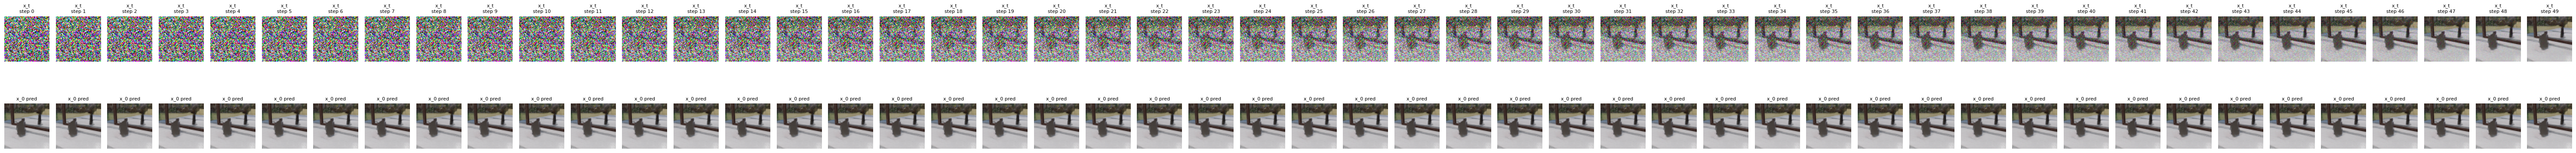

In [15]:
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

# 图像个数
num_steps = len(xts)
fig, axs = plt.subplots(2, num_steps, figsize=(num_steps * 1.2, 2.5 * 2))

for i in range(num_steps):
    xt_img = TF.to_pil_image(torch.clamp((xts[i][0] + 1) / 2, 0, 1))
    x0_img = TF.to_pil_image(torch.clamp((x0_preds[i][0] + 1) / 2, 0, 1))
    
    axs[0, i].imshow(xt_img)
    axs[0, i].set_title(f"x_t\nstep {i}", fontsize=8)
    axs[0, i].axis('off')

    axs[1, i].imshow(x0_img)
    axs[1, i].set_title("x_0 pred", fontsize=8)
    axs[1, i].axis('off')

plt.tight_layout()
plt.show()


In [6]:
import os
import torch
import torchvision.transforms.functional as TF
from torch.cuda.amp import autocast
import torch.nn.functional as F

def smc_guided_sampler(
    model,
    latents,
    y,
    score_fn,               # function: PIL.Image → float
    num_particles=8,
    num_steps=20,
    resample_interval=4,
    resample_beta=5.0,
    image_size=128,
    cfg_scale=1.0,
    guidance_low=0.0,
    guidance_high=1.0,
    num_classes=1000,
    init_noise_std=1e-2,
    return_intermediates=False,
    chunk_size=16
):
    xts = [[] for _ in range(num_steps)]
    x0_preds = [[] for _ in range(num_steps)]
    all_rewards = [[] for _ in range(num_steps)]  # <== 用于保存每一步的reward

    device = latents.device
    t_steps = torch.linspace(1, 0, num_steps + 1, dtype=torch.float64).to(device)
    _dtype = latents.dtype

    batch_size = latents.shape[0]
    assert y.shape[0] == batch_size, f"Mismatch: got {latents.shape[0]} latents and {y.shape[0]} conditions"

    x_particles = latents[:, None, :, :, :].repeat(1, num_particles, 1, 1, 1).reshape(batch_size * num_particles, 3, 64, 64).to(torch.float64)
    if init_noise_std > 0:
        x_particles += torch.randn_like(x_particles) * init_noise_std

    y = y[:, None, :, :].repeat(1, num_particles, 1, 1).reshape(batch_size * num_particles, y.shape[-2], y.shape[-1])

    if cfg_scale > 1.0:
        y_null = torch.zeros_like(y)

    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        print(f"\n🕓 Sampling step {i+1}/{num_steps} | t: {t_cur:.4f} → {t_next:.4f}")
        x_cur = x_particles

        if cfg_scale > 1.0 and guidance_low <= t_cur <= guidance_high:
            model_input = torch.cat([x_cur] * 2, dim=0)
            y_cur = torch.cat([y, y_null], dim=0)
        else:
            model_input = x_cur
            y_cur = y

        time_input = torch.ones(model_input.size(0), device=device, dtype=torch.float64) * t_cur

        d_cur_chunks = []
        for j in range(0, model_input.size(0), chunk_size):
            with autocast(dtype=torch.bfloat16):
                d_chunk = model(
                    model_input[j:j+chunk_size].to(dtype=_dtype),
                    time_input[j:j+chunk_size].to(dtype=_dtype),
                    y=y_cur[j:j+chunk_size]
                )[0].to(torch.float64)
            d_cur_chunks.append(d_chunk)
        d_cur = torch.cat(d_cur_chunks, dim=0)

        if cfg_scale > 1.0 and guidance_low <= t_cur <= guidance_high:
            d_cur_cond, d_cur_uncond = d_cur.chunk(2)
            d_cur = d_cur_uncond + cfg_scale * (d_cur_cond - d_cur_uncond)

        x_next = x_cur + (t_next - t_cur) * d_cur
        x0_pred = x_cur - t_cur * d_cur

        if return_intermediates:
            for p in range(x_particles.size(0)):
                xts[i].append(x_cur[p].detach().clone().to(torch.float32))
                x0_preds[i].append(x0_pred[p].detach().clone().to(torch.float32))

        if (i + 1) % resample_interval == 0 and i < num_steps - 1:
            print(f"🔍 Resampling at step {i+1} (evaluating {x_particles.size(0)} particles...)")
            images = []
            for p in range(x_particles.size(0)):
                img_np = torch.clamp((x0_pred[p] + 1) / 2, 0, 1)
                img_pil = TF.to_pil_image(img_np)
                images.append(img_pil)

            rewards = torch.tensor(
                [score_fn(img) for img in images],
                dtype=torch.float32,
                device=device
            )
            print(f"🎯 Rewards: {[round(r.item(), 2) for r in rewards]}")
            all_rewards[i] = rewards.detach().cpu().tolist()  # <== 保存 reward

            weights = F.softmax(rewards * resample_beta, dim=0)
            resample_idx = torch.multinomial(weights, x_particles.size(0), replacement=True)

            x_next = x_next[resample_idx]
            y = y[resample_idx]

            if return_intermediates:
                xts[i] = [xts[i][j] for j in resample_idx]
                x0_preds[i] = [x0_preds[i][j] for j in resample_idx]

        x_particles = x_next

    if return_intermediates:
        return x_particles, xts, x0_preds, all_rewards
    return x_particles, all_rewards


In [7]:
import random
seed = 42 #12345
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
n = 3  # batch size = 1
quantT = torch.randn(n, vae_embed_dim, dit_input_size, dit_input_size, device=device)

sampling_kwargs_lat = dict(
    model=model,
    latents=quantT,
    y=torch.randint(0, num_classes, (n,), device=device),
    num_steps=num_steps,
    heun=False,
    cfg_scale=cfg_scale,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes
)

with torch.no_grad():
    quant = euler_sampler(**sampling_kwargs_lat).to(torch.float32)
    quant = quant * vq_std + vq_mean  # 反归一化
B, C, H, W = quant.shape  
quant = quant.view(B, C, H * W).permute(0, 2, 1) 

In [8]:
quant.shape

torch.Size([3, 256, 32])

In [8]:
from functools import partial

score_fn = partial(mllm_score, image_size=128, model=mllm_model)

xT = torch.randn(n, 3, resolution, resolution, device=quant.device)
final_latents, xts, x0_preds, all_rewards = smc_guided_sampler(
    model=vae.decoder,
    latents=xT,
    y=quant,
    score_fn=score_fn,
    num_particles=2,
    num_steps=20,
    resample_interval=5,
    resample_beta=6.0,
    init_noise_std = 0,
    return_intermediates=True
)



🕓 Sampling step 1/20 | t: 1.0000 → 0.9500

🕓 Sampling step 2/20 | t: 0.9500 → 0.9000

🕓 Sampling step 3/20 | t: 0.9000 → 0.8500

🕓 Sampling step 4/20 | t: 0.8500 → 0.8000

🕓 Sampling step 5/20 | t: 0.8000 → 0.7500
🔍 Resampling at step 5 (evaluating 6 particles...)


output_text: ["The score is 0. The reason is that there are noticeable inconsistencies between the object and its reflection. The object appears to be a small figure, possibly a toy or figurine, but the reflection does not match this description. Instead, it seems to be a distorted or incomplete reflection, lacking details and appearing as if it's not fully rendered. This suggests a significant inconsistency in the reflection, making it unrealistic."]
output_text: ["The score is 0. The reason is that there are noticeable inconsistencies between the object and its reflection. The object appears to be a small figure, possibly a toy or figurine, but the reflection does not match this description. Instead, it seems to be a distorted or incomplete reflection, lacking details and appearing as if it's not fully rendered. This suggests a significant inconsistency in the reflection, making it unrealistic."]
output_text: ['The score is 0. The reason is that there is a significant inconsistency b

In [11]:
all_rewards

[[],
 [],
 [],
 [],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [],
 [],
 [],
 [],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [],
 [],
 [],
 [],
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 [],
 [],
 [],
 [],
 []]

In [12]:
import os
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image

def visualize_smc_sampling_steps(
    xts, x0_preds, rewards=None, save_dir=None,
    num_samples=3, particles_per_sample=2
):
    os.makedirs(save_dir, exist_ok=True)
    num_steps = len(xts)
    total_particles = num_samples * particles_per_sample

    for step in range(num_steps):
        # 如果该步没有 reward，就跳过显示 score
        has_reward = rewards is not None and len(rewards[step]) > 0

        fig, axs = plt.subplots(num_samples, particles_per_sample * 2, figsize=(particles_per_sample * 4.5, num_samples * 2.5))

        if num_samples == 1:
            axs = axs.reshape(1, -1)
        if particles_per_sample == 1:
            axs = axs.reshape(-1, 2)

        for s in range(num_samples):
            for p in range(particles_per_sample):
                idx = s * particles_per_sample + p
                xt = xts[step][idx]
                x0 = x0_preds[step][idx]

                xt_img = TF.to_pil_image(torch.clamp((xt + 1) / 2, 0, 1))
                x0_img = TF.to_pil_image(torch.clamp((x0 + 1) / 2, 0, 1))

                # x_t
                axs[s, p * 2].imshow(xt_img)
                axs[s, p * 2].axis('off')
                axs[s, p * 2].set_title(f"Sample {s} | P{p+1} x_t")

                # x_0_pred + reward
                axs[s, p * 2 + 1].imshow(x0_img)
                axs[s, p * 2 + 1].axis('off')

                if has_reward:
                    score = rewards[step][idx]
                    score_text = f"Score: {score:.2f}"
                else:
                    score_text = ""
                axs[s, p * 2 + 1].set_title(f"Sample {s} | P{p+1} x₀\n{score_text}")

        plt.suptitle(f"SMC Sampling - Step {step + 1}", fontsize=14)
        plt.tight_layout()
        save_path = os.path.join(save_dir, f"all_samples_step_{step+1:02d}.png")
        plt.savefig(save_path)
        plt.close(fig)


In [13]:
visualize_smc_sampling_steps(
    xts=xts,
    x0_preds=x0_preds,
    rewards=all_rewards,   # or None
    save_dir="/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/sampling_steps_ori/smc",
    num_samples=3,
    particles_per_sample=2
)


In [1]:
# --- 环境导入 ---
import sys
sys.path.append('/cpfs04/user/hanyujin/rule-gen/rule_tokenizer')
import torch
from modelling.sit import SiT_models
from modelling.tokenizer import SoftVQModel
from modelling.samplers import euler_sampler
from utils.model import build_tokenizer
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
# --- 参数配置 ---
vae_config_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp007-aediff-16.yaml"
vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mirror-exp001-aediff-16/checkpoints/0040000.pt"
sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mirror-000-SiT-B-1-linear-uniform-0040000.pt/checkpoints/0120000.pt"

vq_mean = 0.23553907839716345
vq_std = 1.356034517288208

model_name = "SiT-B/1"
num_classes = 3
resolution = 64
path_type = "linear"
cfg_scale = 4.0
num_steps = 50
guidance_low = 0.0
guidance_high = 0.7

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

with open(vae_config_path, 'r') as f:
    config_args = yaml.YAML().load(f)
    dataset = config_args['dataset']
    vq_model = config_args['vq_model']

vae, vae_string_name, vae_embed_dim, dit_input_size, _, _, vae_1d = build_tokenizer(vae_config_path, vae_ckpt_path)
vae = vae.to(device).eval()
print(f"Loaded VAE: embed_dim={vae_embed_dim}, input_size={dit_input_size}, 1d={vae_1d}")


block_kwargs = {"fused_attn": False, "flash_attn": True, "qk_norm": False}
model = SiT_models[model_name](
    in_channels=vae_embed_dim,
    input_size=dit_input_size,
    num_classes=num_classes,
    use_cfg=True,
    z_dims=[0],
    vae_1d=vae_1d,
    **block_kwargs,
)
state_dict = torch.load(sit_ckpt_path, map_location=device)['ema']
model.load_state_dict(state_dict, strict=False)
model = model.to(device).eval()
print("Loaded SiT model.")

from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
# from transformers import AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct"

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

# local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/QVQ-72B-Preview"

# mllm_model = Qwen2VLForConditionalGeneration.from_pretrained(
#     local_path, torch_dtype="auto", device_map="auto"
# )

processor = AutoProcessor.from_pretrained(local_path)

import re
import torch
import gc
import re
from qwen_vl_utils import process_vision_info

def mllm_score(image_input, image_size=128, model=None):
    """
    用 Qwen2.5-VL 模型对图片进行评分，返回整数分数 [0,1,2,...,10]
    """
    try:
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image_input,
                        "resized_height": image_size,
                        "resized_width": image_size
                    },
                    {
                        "type": "text",
                        "text": (
                            "You are an expert in visual anomaly detection. You will be shown images featuring an object in front of a mirror and its reflection. "
                            "Evaluate whether the object and its mirror image are consistent in terms of contour, shape, pose, and spatial alignment. "
                            "Score 0 — Clearly unrealistic: significant inconsistency or visual errors in reflection (e.g., different pose, missing parts). "
                            "Score 1 Fully realistic: the reflection matches the real object with no noticeable anomalies. "
                            "Please answer in the format: The score is {your_score}. The reason is {your_reason}."
                        )
                    }
                ],
            }
        ]

        # 输入预处理
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        ).to("cuda")

        # 推理
        with torch.no_grad():
            generated_ids = model.generate(**inputs, max_new_tokens=512)
            generated_ids_trimmed = [
                out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
            ]
            output_text = processor.batch_decode(
                generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
            )

        print("output_text:", output_text)

        # 正则提取分数
        pattern1 = r"The score is (\d+)"
        pattern2 = r"\*\*Final Answer\*\*.*?(\d+)"
        for pattern in [pattern1, pattern2]:
            match = re.search(pattern, output_text[0], re.DOTALL)
            if match:
                return int(match.group(1))

        print("⚠️ Could not parse score from model output.")
        return 0  # fallback

    except Exception as e:
        print(f"⚠️ mllm_score error: {e}")
        return 0  # fallback

    finally:
        torch.cuda.empty_cache()
        gc.collect()

import re

def extract_score_after_final_answer(output_text):
    """
    从给定文本中查找 **Final Answer** 后面出现的第一个数字，并返回其整数值。
    如果未找到，则抛出 ValueError。
    """
    # 若 output_text 是列表，则默认取第一个元素
    if isinstance(output_text, list):
        text_to_search = output_text[0]
    else:
        text_to_search = output_text

    # 正则：匹配 "**Final Answer**" 后，任意字符(含换行)，再遇到数字(\d+)
    pattern = r"\*\*Final Answer\*\*.*?(\d+)"
    match = re.search(pattern, text_to_search, re.DOTALL)

    if match:
        return int(match.group(1))
    else:
        raise ValueError(f"No number found after **Final Answer** in: {text_to_search}")


import os
import torch
import torchvision.transforms.functional as TF
from torch.cuda.amp import autocast
import torch.nn.functional as F


def smc_guided_sampler(
    model,
    latents,
    y,
    score_fn,
    num_particles=8,
    num_steps=20,
    resample_interval=4,
    resample_beta=5.0,
    image_size=64,
    cfg_scale=1.0,
    guidance_low=0.0,
    guidance_high=1.0,
    num_classes=1000,
    init_noise_std=1e-2,
    return_intermediates=False,
    chunk_size=16,
):
    xts = [[] for _ in range(num_steps)]
    x0_preds = [[] for _ in range(num_steps)]
    all_rewards = [[] for _ in range(num_steps)]

    device = latents.device
    t_steps = torch.linspace(1, 0, num_steps + 1, dtype=torch.float64).to(device)
    _dtype = latents.dtype
    skip_resampling = False  # 🔁 控制是否跳过后续所有 resample + reward

    batch_size = latents.shape[0]
    assert y.shape[0] == batch_size, f"Mismatch: got {latents.shape[0]} latents and {y.shape[0]} conditions"

    x_particles = latents[:, None, :, :, :].repeat(1, num_particles, 1, 1, 1).reshape(
        batch_size * num_particles, 3, image_size, image_size
    ).to(torch.float64)
    if init_noise_std > 0:
        x_particles += torch.randn_like(x_particles) * init_noise_std

    y = y[:, None, :, :].repeat(1, num_particles, 1, 1).reshape(
        batch_size * num_particles, y.shape[-2], y.shape[-1]
    )

    if cfg_scale > 1.0:
        y_null = torch.zeros_like(y)

    for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
        print(f"\n🕓 Sampling step {i+1}/{num_steps} | t: {t_cur:.4f} → {t_next:.4f}")

        x_cur = x_particles

        if cfg_scale > 1.0 and guidance_low <= t_cur <= guidance_high:
            model_input = torch.cat([x_cur] * 2, dim=0)
            y_cur = torch.cat([y, y_null], dim=0)
        else:
            model_input = x_cur
            y_cur = y

        time_input = torch.ones(model_input.size(0), device=device, dtype=torch.float64) * t_cur

        d_cur_chunks = []
        for j in range(0, model_input.size(0), chunk_size):
            with autocast(dtype=torch.bfloat16):
                d_chunk = model(
                    model_input[j:j+chunk_size].to(dtype=_dtype),
                    time_input[j:j+chunk_size].to(dtype=_dtype),
                    y=y_cur[j:j+chunk_size]
                )[0].to(torch.float64)
            d_cur_chunks.append(d_chunk)
        d_cur = torch.cat(d_cur_chunks, dim=0)
        del d_cur_chunks

        if cfg_scale > 1.0 and guidance_low <= t_cur <= guidance_high:
            d_cur_cond, d_cur_uncond = d_cur.chunk(2)
            d_cur = d_cur_uncond + cfg_scale * (d_cur_cond - d_cur_uncond)

        x_next = x_cur + (t_next - t_cur) * d_cur
        x0_pred = x_cur - t_cur * d_cur

        if return_intermediates:
            for p in range(x_particles.size(0)):
                xts[i].append(x_cur[p].detach().clone().to(torch.float32))
                x0_preds[i].append(x0_pred[p].detach().clone().to(torch.float32))

        # ⚠️ 判断是否还继续打分 + 重采样
        if not skip_resampling and (i + 1) % resample_interval == 0 and i < num_steps - 1:
            print(f"🔍 Resampling at step {i+1} (evaluating {x_particles.size(0)} particles...)")
            images = []
            for p in range(x_particles.size(0)):
                img_np = torch.clamp((x0_pred[p] + 1) / 2, 0, 1)
                img_pil = TF.to_pil_image(img_np)
                images.append(img_pil)

            torch.cuda.empty_cache()

            rewards = torch.tensor(
                [score_fn(img) for img in images],
                dtype=torch.float32,
                device=device
            )
            all_rewards[i] = rewards.detach().cpu().tolist()

            # ✅ 如果所有 reward 都是 1，跳过后续打分
            if torch.allclose(rewards, torch.ones_like(rewards)):
                print("✅ All rewards == 1.0, skipping future resampling.")
                skip_resampling = True
            else:
                weights = F.softmax(rewards * resample_beta, dim=0)
                resample_idx = torch.multinomial(weights, x_particles.size(0), replacement=True)
                x_next = x_next[resample_idx]
                y = y[resample_idx]
                # if return_intermediates:
                #     xts[i] = [xts[i][j] for j in resample_idx]
                #     x0_preds[i] = [x0_preds[i][j] for j in resample_idx]

            del rewards, images
            torch.cuda.empty_cache()
            gc.collect()
        else:
            all_rewards[i] = [None] * x_particles.size(0)

        x_particles = x_next

    if return_intermediates:
        return x_particles, xts, x0_preds, all_rewards
    return x_particles, all_rewards

import os
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from PIL import Image

def visualize_smc_sampling_steps(
    xts, x0_preds, rewards=None, save_dir=None,
    num_samples=3, particles_per_sample=2
):
    os.makedirs(save_dir, exist_ok=True)
    num_steps = len(xts)
    total_particles = num_samples * particles_per_sample

    for step in range(num_steps):
        # 如果该步没有 reward，就跳过显示 score
        has_reward = rewards is not None and len(rewards[step]) > 0

        fig, axs = plt.subplots(num_samples, particles_per_sample * 2, figsize=(particles_per_sample * 4.5, num_samples * 2.5))

        if num_samples == 1:
            axs = axs.reshape(1, -1)
        if particles_per_sample == 1:
            axs = axs.reshape(-1, 2)

        for s in range(num_samples):
            for p in range(particles_per_sample):
                idx = s * particles_per_sample + p
                xt = xts[step][idx]
                x0 = x0_preds[step][idx]

                xt_img = TF.to_pil_image(torch.clamp((xt + 1) / 2, 0, 1))
                x0_img = TF.to_pil_image(torch.clamp((x0 + 1) / 2, 0, 1))

                # x_t
                axs[s, p * 2].imshow(xt_img)
                axs[s, p * 2].axis('off')
                axs[s, p * 2].set_title(f"Sample {s} | P{p+1} x_t")

                # x_0_pred + reward
                axs[s, p * 2 + 1].imshow(x0_img)
                axs[s, p * 2 + 1].axis('off')

                if has_reward:
                    score = rewards[step][idx]
                    if score is not None:
                        score_text = f"Score: {score:.2f}"
                    else:
                        score_text = ""
                else:
                    score_text = ""
                axs[s, p * 2 + 1].set_title(f"Sample {s} | P{p+1} x₀\n{score_text}")

        plt.suptitle(f"SMC Sampling - Step {step + 1}", fontsize=14)
        plt.tight_layout()
        save_path = os.path.join(save_dir, f"all_samples_step_{step+1:02d}.png")
        plt.savefig(save_path)
        plt.close(fig)


import random
# seed = 42 #12345
# torch.manual_seed(seed)
# np.random.seed(seed)
# random.seed(seed)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(seed)
n = 6  # batch size = 1
quantT = torch.randn(n, vae_embed_dim, dit_input_size, dit_input_size, device=device)

sampling_kwargs_lat = dict(
    model=model,
    latents=quantT,
    y=torch.randint(0, num_classes, (n,), device=device),
    num_steps=num_steps,
    heun=False,
    cfg_scale=cfg_scale,
    guidance_low=guidance_low,
    guidance_high=guidance_high,
    path_type=path_type,
    num_classes=num_classes
)

with torch.no_grad():
    quant = euler_sampler(**sampling_kwargs_lat).to(torch.float32)
    quant = quant * vq_std + vq_mean  # 反归一化
B, C, H, W = quant.shape  
quant = quant.view(B, C, H * W).permute(0, 2, 1) 
del model
torch.cuda.empty_cache()
gc.collect()

from functools import partial

score_fn = partial(mllm_score, image_size=128, model=mllm_model)

xT = torch.randn(n, 3, resolution, resolution, device=quant.device)
final_latents, xts, x0_preds, all_rewards = smc_guided_sampler(
    model=vae.decoder,
    latents=xT,
    y=quant,
    score_fn=score_fn,
    num_particles=1,
    num_steps=20,
    resample_interval=5,
    resample_beta=6.0,
    init_noise_std = 0,
    return_intermediates=True
)

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-06 19:57:04.693043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-06 19:57:04.708259: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743940624.725200 2827996 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743940624.730101 2827996 cuda_blas.cc:1407] Un

Using device: cuda:1
<All keys matched successfully>
Loaded VAE: embed_dim=32, input_size=16, 1d=False
Loaded SiT model.


Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  1.81it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



🕓 Sampling step 1/20 | t: 1.0000 → 0.9500

🕓 Sampling step 2/20 | t: 0.9500 → 0.9000

🕓 Sampling step 3/20 | t: 0.9000 → 0.8500

🕓 Sampling step 4/20 | t: 0.8500 → 0.8000

🕓 Sampling step 5/20 | t: 0.8000 → 0.7500
🔍 Resampling at step 5 (evaluating 6 particles...)
output_text: ['The score is 0. The reason is that there is a noticeable difference between the object and its reflection. The object appears to be a small, dark object on the ground, but its reflection seems to be distorted and incomplete, lacking details that would make it look like a proper reflection. This suggests a significant inconsistency in the reflection, making it unrealistic.']
output_text: ["The score is 1. The reason is that the object and its reflection appear to be consistent in terms of contour, shape, pose, and spatial alignment. The object's position and orientation in the reflection match the real object, indicating a realistic mirror image."]
output_text: ['The score is 1. The reason is that the object an

In [2]:
visualize_smc_sampling_steps(
    xts=xts,
    x0_preds=x0_preds,
    rewards=all_rewards,   # or None
    save_dir="/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/sampling_steps_ori/smc",
    num_samples=3,
    particles_per_sample=2
)
